#Projeto PCD: K-means 1D (naive) com Paralelização Progressiva

##Algoritmo K-Means (Sequencial)

In [ ]:
%%writefile kmeans_1d_naive.c

/* kmeans_1d_naive.c
K-means 1D (C99), implementação "naive":
- Lê X (N linhas, 1 coluna) e C_init (K linhas, 1 coluna) de CSVs sem cabeça
- Itera assignment + update até max_iter ou variação relativa do SSE < eps.
- Salva (opcional) assign (N linhas) e centróides finais (K linhas).

Compilar: gcc -O2 -std=c99 kmeans_1d_naive.c -o kmeans_1d_naive -lm
Uso: ./kmeans_1d_naive dados.csv centroides_iniciais.csv [max_iter=50]
*/

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>

/* ---------- util CSV 1D: cada linha tem 1 número ---------- */
static int count_rows(const char *path){
	FILE *f = fopen(path, "r");
	if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); exit(1); }
	int rows = 0;
	char line[8192];
	while(fgets(line, sizeof(line), f)){
		int only_ws = 1;
		for(char *p = line; *p; p++){
			if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws = 0; break; }
		}
		if(!only_ws) rows++;
	}
	fclose(f);
	return rows;
}

static double *read_csv_1col(const char *path, int *n_out){
	int R = count_rows(path);
	if(R<=0){ fprintf(stderr,"Arquivo vazio: %s\n", path); exit(1); }
	double *A = (double*)malloc((size_t)R * sizeof(double));
	if(!A){ fprintf(stderr,"Sem memoria para %d linhas\n", R); exit(1); }
	FILE *f = fopen(path, "r");
	if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); free(A); exit(1); }
	char line[8192];
	int r = 0;
	const char *delim = ",; \t\r\n";
	while(fgets(line, sizeof(line), f)){
		int only_ws = 1;
		for(char *p = line; *p; p++){
			if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws = 0; break; }
		}
		if(only_ws) continue;
		char *tok = strtok(line, delim);
		if(!tok){ fprintf(stderr,"Linha %d sem valor em %s\n", r+1, path); free(A); fclose(f); exit(1); }
		A[r] = atof(tok);
		r++;
		if(r >= R) break;
	}
	fclose(f);
	*n_out = r;
	return A;
}

static void write_assign_csv(const char *path, const int *assign, int N){
	if(!path) return;
	FILE *f = fopen(path, "w");
	if(!f){ fprintf(stderr,"Erro ao abrir %s para escrita\n", path); return; }
	for(int i=0;i<N;i++) fprintf(f, "%d\n", assign[i]);
	fclose(f);
}
static void write_centroids_csv(const char *path, const double *C, int K){
	if(!path) return;
	FILE *f = fopen(path, "w");
	if(!f){ fprintf(stderr,"Erro ao abrir %s para escrita\n", path); return; }
	for(int c=0;c<K;c++) fprintf(f, "%.6f\n", C[c]);
	fclose(f);
}

/* ---------- k-means 1D ---------- */
/* assignment: para cada X[i], encontra c com menor (X[i]-C[c])^2 */
static double assignment_step_1d(const double *X, const double *C, int *assign, int N, int K){
	double sse = 0.0;
	for(int i=0;i<N;i++){
		int best = -1;
		double bestd = 1e300;
		for(int c=0;c<K;c++){
			double diff = X[i] - C[c];
			double d = diff*diff;
			if(d < bestd){ bestd = d; best = c; }
		}
		assign[i] = best;
		sse += bestd;
	}
	return sse;
}

/* update: média dos pontos de cada cluster (1D)
   se cluster vazio, copia X[0] (estratégia naive) */
static void update_step_1d(const double *X, double *C, const int *assign, int N, int K){
	double *sum = (double*)calloc((size_t)K, sizeof(double));
	int *cnt = (int*)calloc((size_t)K, sizeof(int));
	if(!sum || !cnt){ fprintf(stderr,"Sem memoria no update\n"); exit(1); }
	for(int i=0;i<N;i++){
		int a = assign[i];
		if(a >= 0 && a < K){
			cnt[a] += 1;
			sum[a] += X[i];
		}
	}
	for(int c=0;c<K;c++){
		if(cnt[c] > 0) C[c] = sum[c] / (double)cnt[c];
		else C[c] = X[0]; /* simples: cluster vazio recebe o primeiro ponto */
	}
	free(sum); free(cnt);
}

static void kmeans_1d(const double *X, double *C, int *assign,
					  int N, int K, int max_iter, double eps,
					  int *iters_out, double *sse_out)
{
	double prev_sse = 1e300;
	double sse = 0.0;
	int it;
	for(it=0; it<max_iter; it++){
		sse = assignment_step_1d(X, C, assign, N, K);
		/* parada por variação relativa do SSE */
		double rel = fabs(sse - prev_sse) / (prev_sse > 0.0 ? prev_sse : 1.0);
		if(rel < eps){ it++; break; }
		update_step_1d(X, C, assign, N, K);
		prev_sse = sse;
	}
	*iters_out = it;
	*sse_out = sse;
}

/* ---------- main ---------- */
int main(int argc, char **argv){
	if(argc < 3){
		printf("Uso: %s dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] [out_assign.csv] [out_centroids.csv]\n", argv[0]);
		printf("Obs: arquivos CSV com 1 coluna (1 valor por linha), sem cabecalho\n");
		return 1;
	}
	const char *pathX = argv[1];
	const char *pathC = argv[2];
	int max_iter = (argc>3)? atoi(argv[3]) : 50;
	double eps = (argc>4)? atof(argv[4]) : 1e-4;
	const char *outAssign = (argc>5)? argv[5] : NULL;
	const char *outCentroid = (argc>6)? argv[6] : NULL;
	if(max_iter <= 0 || eps <= 0.0){
		fprintf(stderr,"Parâmetros inválidos: max_iter>0 e eps>0\n");
		return 1;
	}
	int N=0, K=0;
	double *X = read_csv_1col(pathX, &N);
	double *C = read_csv_1col(pathC, &K);
	if(!X || !C){ fprintf(stderr,"Erro ao ler arquivos de entrada\n"); free(X); free(C); return 1; }
	int *assign = (int*)malloc((size_t)N * sizeof(int));
	if(!assign){ fprintf(stderr,"Sem memoria para assign\n"); free(X); free(C); return 1; }

	clock_t t0 = clock();
	int iters = 0; double sse = 0.0;
	kmeans_1d(X, C, assign, N, K, max_iter, eps, &iters, &sse);
	clock_t t1 = clock();
	double ms = 1000.0 * (double)(t1 - t0) / (double)CLOCKS_PER_SEC;
	printf("K-means 1D (naive)\n");
	printf("N=%d K=%d max_iter=%d eps=%g\n", N, K, max_iter, eps);
	printf("Iterações: %d | SSE final: %.6f | Tempo: %.1f ms\n", iters, sse, ms);

	write_assign_csv(outAssign, assign, N);
	write_centroids_csv(outCentroid, C, K);
	free(assign); free(X); free(C);
	return 0;
}

Overwriting kmeans_1d_naive.c


##Dados

In [ ]:
import numpy as np

for N in [10_000, 100_000, 1_000_000]:
    X = np.random.uniform(low=0, high=100, size=N)
    np.savetxt(f'dados_{N}.csv', X, fmt='%.6f')
    print(f'Arquivo dados_{N}.csv criado!')

Arquivo dados_10000.csv criado!
Arquivo dados_100000.csv criado!
Arquivo dados_1000000.csv criado!


##Centróides Iniciais

In [ ]:
%%writefile centroides_iniciais.csv

10
30
60
90

Overwriting centroides_iniciais.csv


##Etapa 2 — CUDA (GPU)

###Algoritmo K-Means (CUDA - GPU)

In [ ]:
%%writefile kmeans_1d_cuda.cu

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <cuda_runtime.h>

#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if(err != cudaSuccess) { \
            fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
            exit(1); \
        } \
    } while(0)

// Centróides em memória constante (máx 64KB, ~8000 floats)
__constant__ float C_const[8192];

/* ---------- Funções de leitura CSV ---------- */
static int count_rows(const char *path){
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); exit(1); }
    int rows = 0;
    char line[8192];
    while(fgets(line, sizeof(line), f)){
        int only_ws = 1;
        for(char *p = line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws = 0; break; }
        }
        if(!only_ws) rows++;
    }
    fclose(f);
    return rows;
}

static double *read_csv_1col(const char *path, int *n_out){
    int R = count_rows(path);
    if(R<=0){ fprintf(stderr,"Arquivo vazio: %s\n", path); exit(1); }
    double *A = (double*)malloc((size_t)R * sizeof(double));
    if(!A){ fprintf(stderr,"Sem memoria para %d linhas\n", R); exit(1); }
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); free(A); exit(1); }
    char line[8192];
    int r = 0;
    const char *delim = ",; \t\r\n";
    while(fgets(line, sizeof(line), f)){
        int only_ws = 1;
        for(char *p = line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws = 0; break; }
        }
        if(only_ws) continue;
        char *tok = strtok(line, delim);
        if(!tok){ fprintf(stderr,"Linha %d sem valor em %s\n", r+1, path); free(A); fclose(f); exit(1); }
        A[r] = atof(tok);
        r++;
        if(r >= R) break;
    }
    fclose(f);
    *n_out = r;
    return A;
}

/* ---------- Função de escrita de resultados ---------- */
static void write_results_csv(const char *path, int N, int K, int block_size, int max_iter,
                              double eps, int iterations, double sse,
                              double time_h2d, double time_kernel, double time_d2h, double time_total,
                              const double *centroids){
    if(!path) return;
    FILE *f = fopen(path, "w");
    if(!f){
        fprintf(stderr,"Erro ao abrir %s para escrita\n", path);
        return;
    }

    // Cabeçalho
    fprintf(f, "metric,value\n");

    // Configuração
    fprintf(f, "N,%d\n", N);
    fprintf(f, "K,%d\n", K);
    fprintf(f, "block_size,%d\n", block_size);
    fprintf(f, "max_iter,%d\n", max_iter);
    fprintf(f, "eps,%.6e\n", eps);

    // Resultados
    fprintf(f, "iterations,%d\n", iterations);
    fprintf(f, "final_sse,%.6f\n", sse);

    // Tempos
    fprintf(f, "time_h2d_ms,%.3f\n", time_h2d);
    fprintf(f, "time_kernel_ms,%.3f\n", time_kernel);
    fprintf(f, "time_d2h_ms,%.3f\n", time_d2h);
    fprintf(f, "time_total_ms,%.3f\n", time_total);

    // Métricas derivadas
    double throughput = (double)N / (time_total / 1000.0);
    double avg_time_per_iter = time_total / (double)iterations;
    fprintf(f, "throughput_pts_per_sec,%.2f\n", throughput);
    fprintf(f, "avg_time_per_iteration_ms,%.3f\n", avg_time_per_iter);

    // Centróides finais
    for(int c = 0; c < K; c++){
        fprintf(f, "centroid_%d,%.6f\n", c, centroids[c]);
    }

    fclose(f);
}

/* ---------- CUDA Kernels ---------- */

// Kernel de assignment: 1 thread por ponto i
// Usa memória constante para centróides
__global__ void assignment_step_1d_gpu(const float *X, int *assign, float *errors, int N, int K) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if(i >= N) return;

    int best = -1;
    float bestd = 1e30f;
    float xi = X[i];

    // Varre K centróides da memória constante
    for(int c = 0; c < K; c++){
        float diff = xi - C_const[c];
        float d = diff * diff;
        if(d < bestd){
            bestd = d;
            best = c;
        }
    }

    assign[i] = best;
    errors[i] = bestd; // Erro individual para redução posterior
}

// Kernel de redução em blocos para SSE (redução paralela)
__global__ void reduce_sse_kernel(const float *errors, float *block_sums, int N) {
    extern __shared__ float sdata[];

    int tid = threadIdx.x;
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    // Carrega dados na shared memory
    sdata[tid] = (i < N) ? errors[i] : 0.0f;
    __syncthreads();

    // Redução em árvore
    for(int s = blockDim.x/2; s > 0; s >>= 1) {
        if(tid < s) {
            sdata[tid] += sdata[tid + s];
        }
        __syncthreads();
    }

    // Thread 0 escreve resultado do bloco
    if(tid == 0) {
        block_sums[blockIdx.x] = sdata[0];
    }
}

// Kernel de update com atomics
__global__ void update_step_1d_gpu(const float *X, const int *assign, float *sum, int *count, int N, int K) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if(i >= N) return;

    int a = assign[i];
    if(a >= 0 && a < K){
        atomicAdd(&sum[a], X[i]);
        atomicAdd(&count[a], 1);
    }
}

/* ---------- Host function: k-means main loop com medições ---------- */
void kmeans_1d_gpu(const double *X_host, double *C_host, int *assign_host,
                   int N, int K, int max_iter, double eps, int block_size,
                   int *iters_out, double *sse_out,
                   double *time_h2d, double *time_d2h, double *time_kernel, double *time_total)
{
    cudaEvent_t start, stop, start_total, stop_total;
    cudaEvent_t start_h2d, stop_h2d, start_d2h, stop_d2h, start_kernel, stop_kernel;
    float ms_temp;

    cudaEventCreate(&start_total); cudaEventCreate(&stop_total);
    cudaEventCreate(&start_h2d); cudaEventCreate(&stop_h2d);
    cudaEventCreate(&start_d2h); cudaEventCreate(&stop_d2h);
    cudaEventCreate(&start_kernel); cudaEventCreate(&stop_kernel);
    cudaEventCreate(&start); cudaEventCreate(&stop);

    cudaEventRecord(start_total);

    // Conversão para float
    float *Xf = (float*)malloc(N*sizeof(float));
    float *Cf = (float*)malloc(K*sizeof(float));
    for(int i=0; i<N; i++) Xf[i] = (float)X_host[i];
    for(int i=0; i<K; i++) Cf[i] = (float)C_host[i];

    // Alocação na GPU
    float *d_X, *d_errors, *d_sum, *d_block_sums;
    int *d_assign, *d_count;

    CUDA_CHECK(cudaMalloc(&d_X, N*sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_assign, N*sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_errors, N*sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_sum, K*sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_count, K*sizeof(int)));

    int grid = (N + block_size - 1) / block_size;
    CUDA_CHECK(cudaMalloc(&d_block_sums, grid*sizeof(float)));

    // Tempo H2D
    cudaEventRecord(start_h2d);
    CUDA_CHECK(cudaMemcpy(d_X, Xf, N*sizeof(float), cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpyToSymbol(C_const, Cf, K*sizeof(float)));
    cudaEventRecord(stop_h2d);
    cudaEventSynchronize(stop_h2d);
    cudaEventElapsedTime(&ms_temp, start_h2d, stop_h2d);
    *time_h2d = ms_temp;

    // Arrays host para update
    float *sum_host = (float*)malloc(K*sizeof(float));
    int *count_host = (int*)malloc(K*sizeof(int));
    float *block_sums_host = (float*)malloc(grid*sizeof(float));

    int it;
    float sse = 0.0f, prev_sse = 1e30f;
    *time_kernel = 0.0;

    for(it = 0; it < max_iter; it++){
        // Assignment step
        cudaEventRecord(start_kernel);
        assignment_step_1d_gpu<<<grid, block_size>>>(d_X, d_assign, d_errors, N, K);
        CUDA_CHECK(cudaDeviceSynchronize());

        // Redução SSE
        int reduce_grid = grid;
        reduce_sse_kernel<<<reduce_grid, block_size, block_size*sizeof(float)>>>(d_errors, d_block_sums, N);
        CUDA_CHECK(cudaDeviceSynchronize());
        cudaEventRecord(stop_kernel);
        cudaEventSynchronize(stop_kernel);
        cudaEventElapsedTime(&ms_temp, start_kernel, stop_kernel);
        *time_kernel += ms_temp;

        // Copia somas dos blocos e finaliza redução no host
        CUDA_CHECK(cudaMemcpy(block_sums_host, d_block_sums, reduce_grid*sizeof(float), cudaMemcpyDeviceToHost));
        sse = 0.0f;
        for(int b = 0; b < reduce_grid; b++) {
            sse += block_sums_host[b];
        }

        // Verifica convergência
        double rel = fabs((double)sse - (double)prev_sse) / (prev_sse > 0.0f ? (double)prev_sse : 1.0);
        if(rel < eps){
            it++;
            break;
        }

        // Update step
        cudaEventRecord(start_kernel);
        CUDA_CHECK(cudaMemset(d_sum, 0, K*sizeof(float)));
        CUDA_CHECK(cudaMemset(d_count, 0, K*sizeof(int)));
        update_step_1d_gpu<<<grid, block_size>>>(d_X, d_assign, d_sum, d_count, N, K);
        CUDA_CHECK(cudaDeviceSynchronize());
        cudaEventRecord(stop_kernel);
        cudaEventSynchronize(stop_kernel);
        cudaEventElapsedTime(&ms_temp, start_kernel, stop_kernel);
        *time_kernel += ms_temp;

        // Copia resultados e calcula novos centróides no host
        CUDA_CHECK(cudaMemcpy(sum_host, d_sum, K*sizeof(float), cudaMemcpyDeviceToHost));
        CUDA_CHECK(cudaMemcpy(count_host, d_count, K*sizeof(int), cudaMemcpyDeviceToHost));

        for(int c = 0; c < K; c++){
            if(count_host[c] > 0)
                Cf[c] = sum_host[c] / (float)count_host[c];
            else
                Cf[c] = Xf[0]; // Cluster vazio
        }

        // Atualiza centróides na memória constante
        CUDA_CHECK(cudaMemcpyToSymbol(C_const, Cf, K*sizeof(float)));

        prev_sse = sse;
    }

    // Tempo D2H
    cudaEventRecord(start_d2h);
    CUDA_CHECK(cudaMemcpy(assign_host, d_assign, N*sizeof(int), cudaMemcpyDeviceToHost));
    cudaEventRecord(stop_d2h);
    cudaEventSynchronize(stop_d2h);
    cudaEventElapsedTime(&ms_temp, start_d2h, stop_d2h);
    *time_d2h = ms_temp;

    // Copia centróides finais
    for(int i = 0; i < K; i++) C_host[i] = (double)Cf[i];

    *iters_out = it;
    *sse_out = (double)sse;

    cudaEventRecord(stop_total);
    cudaEventSynchronize(stop_total);
    cudaEventElapsedTime(&ms_temp, start_total, stop_total);
    *time_total = ms_temp;

    // Limpeza
    CUDA_CHECK(cudaFree(d_X));
    CUDA_CHECK(cudaFree(d_assign));
    CUDA_CHECK(cudaFree(d_errors));
    CUDA_CHECK(cudaFree(d_sum));
    CUDA_CHECK(cudaFree(d_count));
    CUDA_CHECK(cudaFree(d_block_sums));

    free(Xf); free(Cf);
    free(sum_host); free(count_host); free(block_sums_host);

    cudaEventDestroy(start_total); cudaEventDestroy(stop_total);
    cudaEventDestroy(start_h2d); cudaEventDestroy(stop_h2d);
    cudaEventDestroy(start_d2h); cudaEventDestroy(stop_d2h);
    cudaEventDestroy(start_kernel); cudaEventDestroy(stop_kernel);
    cudaEventDestroy(start); cudaEventDestroy(stop);
}

/* ---------- main ---------- */
int main(int argc, char **argv){
    if(argc < 3){
        printf("Uso: %s dados.csv centroides_iniciais.csv [block_size=256] [max_iter=50] [eps=1e-4] [out_results.csv]\n", argv[0]);
        printf("Obs: arquivos CSV com 1 coluna (1 valor por linha), sem cabecalho\n");
        printf("     block_size: 128, 256 ou 512 (padrão: 256)\n");
        return 1;
    }

    const char *pathX = argv[1];
    const char *pathC = argv[2];
    int block_size = (argc>3)? atoi(argv[3]) : 256;
    int max_iter = (argc>4)? atoi(argv[4]) : 50;
    double eps = (argc>5)? atof(argv[5]) : 1e-4;
    const char *outResults = (argc>6)? argv[6] : "results.csv";

    if(block_size <= 0 || max_iter <= 0 || eps <= 0.0){
        fprintf(stderr,"Parâmetros inválidos: block_size>0, max_iter>0 e eps>0\n");
        return 1;
    }

    // Leitura dos dados
    int N=0, K=0;
    double *X = read_csv_1col(pathX, &N);
    double *C = read_csv_1col(pathC, &K);
    if(!X || !C){
        fprintf(stderr,"Erro ao ler arquivos de entrada\n");
        free(X); free(C);
        return 1;
    }

    int *assign = (int*)malloc((size_t)N * sizeof(int));
    if(!assign){
        fprintf(stderr,"Sem memoria para assign\n");
        free(X); free(C);
        return 1;
    }

    // Execução do k-means
    int iters = 0;
    double sse = 0.0;
    double time_h2d = 0.0, time_d2h = 0.0, time_kernel = 0.0, time_total = 0.0;

    kmeans_1d_gpu(X, C, assign, N, K, max_iter, eps, block_size,
                  &iters, &sse, &time_h2d, &time_d2h, &time_kernel, &time_total);

    // Cálculo de métricas
    double throughput = (double)N / (time_total / 1000.0); // pontos por segundo
    int grid = (N + block_size - 1) / block_size;

    // Resultados na tela
    printf("=== K-means 1D (CUDA) ===\n");
    printf("Configuração:\n");
    printf("  N=%d | K=%d | max_iter=%d | eps=%g\n", N, K, max_iter, eps);
    printf("  Block size: %d | Grid size: %d\n", block_size, grid);
    printf("\nResultados:\n");
    printf("  Iterações: %d | SSE final: %.6f\n", iters, sse);
    printf("\nTempos (ms):\n");
    printf("  H2D (Host->Device): %.3f ms\n", time_h2d);
    printf("  Kernels (total):    %.3f ms\n", time_kernel);
    printf("  D2H (Device->Host): %.3f ms\n", time_d2h);
    printf("  Total:              %.3f ms\n", time_total);
    printf("\nDesempenho:\n");
    printf("  Throughput: %.2f pontos/s (%.2f M pontos/s)\n",
           throughput, throughput/1e6);
    printf("  Tempo médio/iteração: %.3f ms\n", time_total / (double)iters);

    // Salva resultados em CSV
    write_results_csv(outResults, N, K, block_size, max_iter, eps,
                     iters, sse, time_h2d, time_kernel, time_d2h, time_total, C);
    printf("\nResultados salvos em: %s\n", outResults);

    free(assign); free(X); free(C);
    return 0;
}

Overwriting kmeans_1d_cuda.cu


##Resultados (N = 10k, 100k e 1M)


In [ ]:
!gcc -O2 -std=c99 kmeans_1d_naive.c -o kmeans_1d_naive -lm
!nvcc -O2 -arch=sm_75 kmeans_1d_cuda.cu -o kmeans_1d_cuda

###Sequencial

In [ ]:
!./kmeans_1d_naive dados_10000.csv centroides_iniciais.csv

K-means 1D (naive)
N=10000 K=4 max_iter=50 eps=0.0001
Iterações: 17 | SSE final: 517680.814119 | Tempo: 1.0 ms


In [ ]:
!./kmeans_1d_naive dados_100000.csv centroides_iniciais.csv

K-means 1D (naive)
N=100000 K=4 max_iter=50 eps=0.0001
Iterações: 15 | SSE final: 5195690.067748 | Tempo: 8.5 ms


In [ ]:
!./kmeans_1d_naive dados_1000000.csv centroides_iniciais.csv

K-means 1D (naive)
N=1000000 K=4 max_iter=50 eps=0.0001
Iterações: 17 | SSE final: 52152727.059341 | Tempo: 108.6 ms


###CUDA - GPU

In [ ]:
!./kmeans_1d_cuda dados_10000.csv centroides_iniciais.csv 128 50 1e-4 results_128_10000.csv

=== K-means 1D (CUDA) ===
Configuração:
  N=10000 | K=4 | max_iter=50 | eps=0.0001
  Block size: 128 | Grid size: 79

Resultados:
  Iterações: 17 | SSE final: 517680.750000

Tempos (ms):
  H2D (Host->Device): 0.252 ms
  Kernels (total):    0.881 ms
  D2H (Device->Host): 0.039 ms
  Total:              2.078 ms

Desempenho:
  Throughput: 4811245.15 pontos/s (4.81 M pontos/s)
  Tempo médio/iteração: 0.122 ms

Resultados salvos em: results_128_10000.csv


In [ ]:
!./kmeans_1d_cuda dados_10000.csv centroides_iniciais.csv 256 50 1e-4 results_256_10000.csv

=== K-means 1D (CUDA) ===
Configuração:
  N=10000 | K=4 | max_iter=50 | eps=0.0001
  Block size: 256 | Grid size: 40

Resultados:
  Iterações: 17 | SSE final: 517680.781250

Tempos (ms):
  H2D (Host->Device): 0.248 ms
  Kernels (total):    0.891 ms
  D2H (Device->Host): 0.040 ms
  Total:              2.118 ms

Desempenho:
  Throughput: 4722041.75 pontos/s (4.72 M pontos/s)
  Tempo médio/iteração: 0.125 ms

Resultados salvos em: results_256_10000.csv


In [ ]:
!./kmeans_1d_cuda dados_10000.csv centroides_iniciais.csv 512 50 1e-4 results_512_10000.csv

=== K-means 1D (CUDA) ===
Configuração:
  N=10000 | K=4 | max_iter=50 | eps=0.0001
  Block size: 512 | Grid size: 20

Resultados:
  Iterações: 17 | SSE final: 517680.843750

Tempos (ms):
  H2D (Host->Device): 0.238 ms
  Kernels (total):    0.915 ms
  D2H (Device->Host): 0.039 ms
  Total:              2.097 ms

Desempenho:
  Throughput: 4768516.88 pontos/s (4.77 M pontos/s)
  Tempo médio/iteração: 0.123 ms

Resultados salvos em: results_512_10000.csv


In [ ]:
!./kmeans_1d_cuda dados_100000.csv centroides_iniciais.csv 128 50 1e-4 results_128_100000.csv

=== K-means 1D (CUDA) ===
Configuração:
  N=100000 | K=4 | max_iter=50 | eps=0.0001
  Block size: 128 | Grid size: 782

Resultados:
  Iterações: 15 | SSE final: 5195693.500000

Tempos (ms):
  H2D (Host->Device): 0.362 ms
  Kernels (total):    3.058 ms
  D2H (Device->Host): 0.324 ms
  Total:              4.802 ms

Desempenho:
  Throughput: 20825003.60 pontos/s (20.83 M pontos/s)
  Tempo médio/iteração: 0.320 ms

Resultados salvos em: results_128_100000.csv


In [ ]:
!./kmeans_1d_cuda dados_100000.csv centroides_iniciais.csv 256 50 1e-4 results_256_100000.csv

=== K-means 1D (CUDA) ===
Configuração:
  N=100000 | K=4 | max_iter=50 | eps=0.0001
  Block size: 256 | Grid size: 391

Resultados:
  Iterações: 15 | SSE final: 5195685.000000

Tempos (ms):
  H2D (Host->Device): 0.351 ms
  Kernels (total):    3.132 ms
  D2H (Device->Host): 0.342 ms
  Total:              4.934 ms

Desempenho:
  Throughput: 20266939.84 pontos/s (20.27 M pontos/s)
  Tempo médio/iteração: 0.329 ms

Resultados salvos em: results_256_100000.csv


In [ ]:
!./kmeans_1d_cuda dados_100000.csv centroides_iniciais.csv 512 50 1e-4 results_512_100000.csv

=== K-means 1D (CUDA) ===
Configuração:
  N=100000 | K=4 | max_iter=50 | eps=0.0001
  Block size: 512 | Grid size: 196

Resultados:
  Iterações: 15 | SSE final: 5195690.500000

Tempos (ms):
  H2D (Host->Device): 0.467 ms
  Kernels (total):    3.271 ms
  D2H (Device->Host): 0.371 ms
  Total:              5.417 ms

Desempenho:
  Throughput: 18461410.61 pontos/s (18.46 M pontos/s)
  Tempo médio/iteração: 0.361 ms

Resultados salvos em: results_512_100000.csv


In [ ]:
!./kmeans_1d_cuda dados_1000000.csv centroides_iniciais.csv 128 50 1e-4 results_128_1000000.csv

=== K-means 1D (CUDA) ===
Configuração:
  N=1000000 | K=4 | max_iter=50 | eps=0.0001
  Block size: 128 | Grid size: 7813

Resultados:
  Iterações: 17 | SSE final: 52152540.000000

Tempos (ms):
  H2D (Host->Device): 1.251 ms
  Kernels (total):    28.885 ms
  D2H (Device->Host): 2.922 ms
  Total:              37.472 ms

Desempenho:
  Throughput: 26686342.63 pontos/s (26.69 M pontos/s)
  Tempo médio/iteração: 2.204 ms

Resultados salvos em: results_128_1000000.csv


In [ ]:
!./kmeans_1d_cuda dados_1000000.csv centroides_iniciais.csv 256 50 1e-4 results_256_1000000.csv

=== K-means 1D (CUDA) ===
Configuração:
  N=1000000 | K=4 | max_iter=50 | eps=0.0001
  Block size: 256 | Grid size: 3907

Resultados:
  Iterações: 17 | SSE final: 52152656.000000

Tempos (ms):
  H2D (Host->Device): 1.208 ms
  Kernels (total):    29.007 ms
  D2H (Device->Host): 2.822 ms
  Total:              37.230 ms

Desempenho:
  Throughput: 26860323.63 pontos/s (26.86 M pontos/s)
  Tempo médio/iteração: 2.190 ms

Resultados salvos em: results_256_1000000.csv


In [ ]:
!./kmeans_1d_cuda dados_1000000.csv centroides_iniciais.csv 512 50 1e-4 results_512_1000000.csv

=== K-means 1D (CUDA) ===
Configuração:
  N=1000000 | K=4 | max_iter=50 | eps=0.0001
  Block size: 512 | Grid size: 1954

Resultados:
  Iterações: 17 | SSE final: 52152624.000000

Tempos (ms):
  H2D (Host->Device): 1.212 ms
  Kernels (total):    29.315 ms
  D2H (Device->Host): 2.774 ms
  Total:              37.221 ms

Desempenho:
  Throughput: 26866374.37 pontos/s (26.87 M pontos/s)
  Tempo médio/iteração: 2.189 ms

Resultados salvos em: results_512_1000000.csv


##Comparação entre Sequencial e CUDA

In [ ]:
import subprocess
import os

def run_command(cmd, output_files):
    """Executa comando e captura saída, salvando em múltiplos arquivos"""
    try:
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=300)
        output = result.stdout + result.stderr

        for output_file in output_files:
            with open(output_file, 'a') as f:
                f.write(f"\n{'='*80}\n")
                f.write(f"Comando: {cmd}\n")
                f.write(f"{'-'*80}\n")
                f.write(output)
                f.write(f"\n{'='*80}\n")
        return output
    except subprocess.TimeoutExpired:
        for output_file in output_files:
            with open(output_file, 'a') as f:
                f.write(f"\n{'='*80}\n")
                f.write(f"Comando: {cmd}\n")
                f.write(f"{'-'*80}\n")
                f.write("TIMEOUT: Command exceeded 5 minutes\n")
                f.write(f"\n{'='*80}\n")
        return "TIMEOUT: Command exceeded 5 minutes"
    except Exception as e:
        for output_file in output_files:
            with open(output_file, 'a') as f:
                f.write(f"\n{'='*80}\n")
                f.write(f"Comando: {cmd}\n")
                f.write(f"{'-'*80}\n")
                f.write(f"ERROR: {str(e)}\n")
                f.write(f"\n{'='*80}\n")
        return f"ERROR: {str(e)}"

def main():
    print("Starting K-means benchmark tests...")
    print("="*80)

    if not os.path.exists('./kmeans_1d_naive'):
        print("Compiling naive implementation...")

        run_command("gcc -o kmeans_1d_naive k_means_naive.c -lm", [
            f"results_naive_1.txt",
            f"results_cuda_1.txt",
            f"results_all_1.txt"
        ])

    if not os.path.exists('./kmeans_1d_cuda'):
        print("Compiling CUDA implementation...")
        run_command("nvcc -o kmeans_1d_cuda k_means_gpu.cu", [
            f"results_naive_1.txt",
            f"results_cuda_1.txt",
            f"results_all_1.txt"
        ])

    print("\nRunning tests...\n")

    for run in range(1, 6):
        print(f"\n=== Teste {run}/5 ===\n")

        naive_file = f"results_naive_{run}.txt"
        cuda_file = f"results_cuda_{run}.txt"
        all_file = f"results_all_{run}.txt"

        # Limpa os arquivos no início de cada
        for f in [naive_file, cuda_file, all_file]:
            open(f, 'w').close()

        # Naive
        run_command("./kmeans_1d_naive dados_10000.csv centroides_iniciais.csv", [naive_file, all_file])
        run_command("./kmeans_1d_naive dados_100000.csv centroides_iniciais.csv", [naive_file, all_file])
        run_command("./kmeans_1d_naive dados_1000000.csv centroides_iniciais.csv", [naive_file, all_file])

        # CUDA
        for bs in [128, 256, 512]:
            run_command(f"./kmeans_1d_cuda dados_10000.csv centroides_iniciais.csv {bs} 50 1e-4", [cuda_file, all_file])
            run_command(f"./kmeans_1d_cuda dados_100000.csv centroides_iniciais.csv {bs} 50 1e-4", [cuda_file, all_file])
            run_command(f"./kmeans_1d_cuda dados_1000000.csv centroides_iniciais.csv {bs} 50 1e-4", [cuda_file, all_file])

        print(f"\nResultados naive: {naive_file}")
        print(f"Resultados cuda: {cuda_file}")
        print(f"Resultados completos: {all_file}")
        print("="*80)

if __name__ == "__main__":
    main()

Starting K-means benchmark tests...

Running tests...


=== Teste 1/5 ===


Resultados naive: results_naive_1.txt
Resultados cuda: results_cuda_1.txt
Resultados completos: results_all_1.txt

=== Teste 2/5 ===


Resultados naive: results_naive_2.txt
Resultados cuda: results_cuda_2.txt
Resultados completos: results_all_2.txt

=== Teste 3/5 ===


Resultados naive: results_naive_3.txt
Resultados cuda: results_cuda_3.txt
Resultados completos: results_all_3.txt

=== Teste 4/5 ===


Resultados naive: results_naive_4.txt
Resultados cuda: results_cuda_4.txt
Resultados completos: results_all_4.txt

=== Teste 5/5 ===


Resultados naive: results_naive_5.txt
Resultados cuda: results_cuda_5.txt
Resultados completos: results_all_5.txt


##Visualização Gráfica

 results_all_1.txt
 results_all_2.txt
 results_all_3.txt
 results_all_4.txt
 results_all_5.txt

────────────────────────────────────────────────────────────────────────────────────────────────────
Dataset: 10,000 pontos
────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────
Dataset: 100,000 pontos
────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────
Dataset: 1,000,000 pontos
────────────────────────────────────────────────────────────────────────────────────────────────────


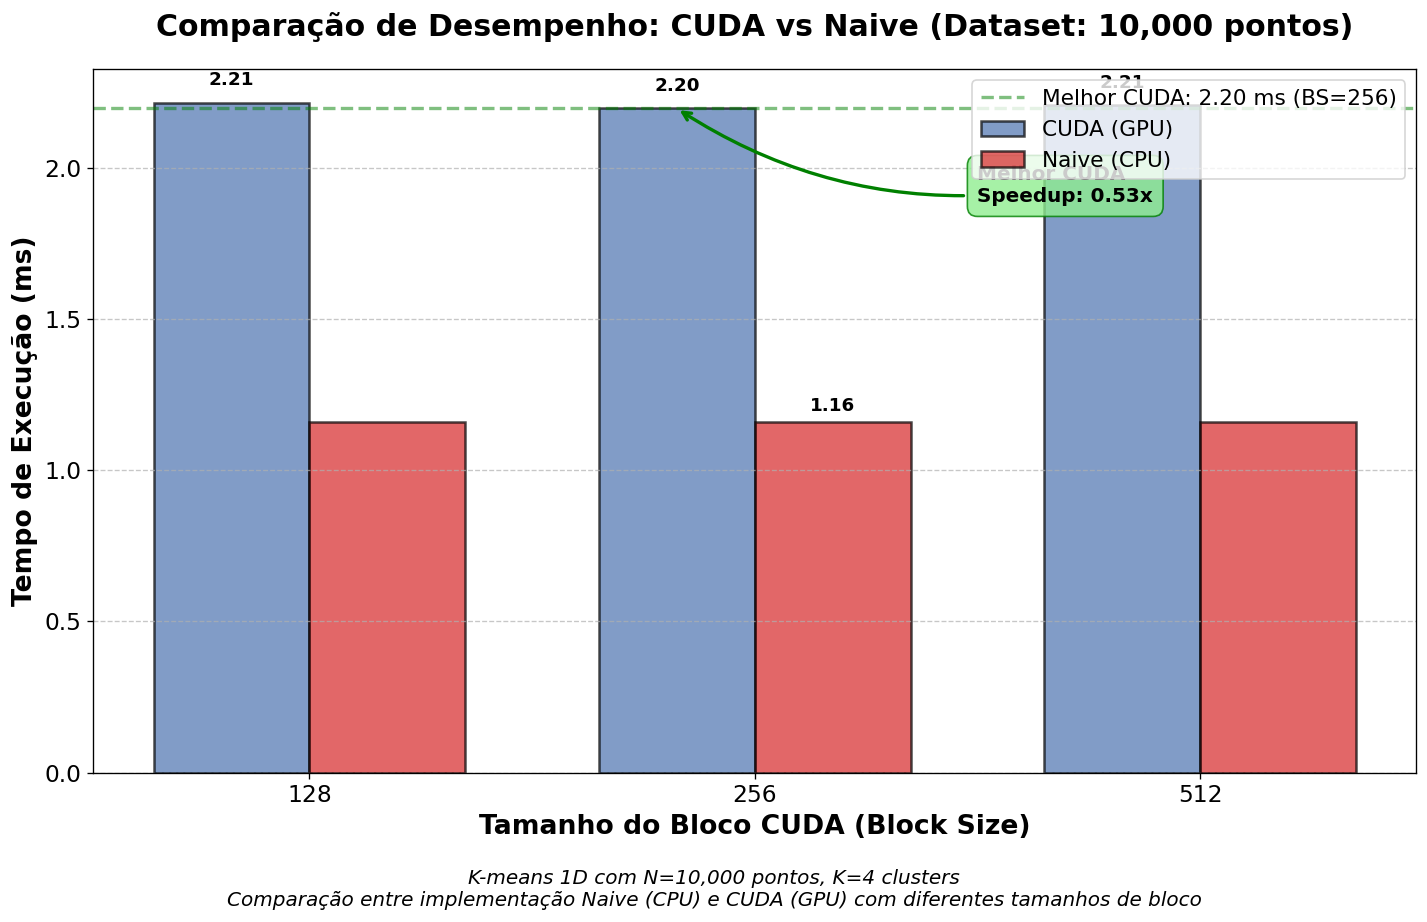

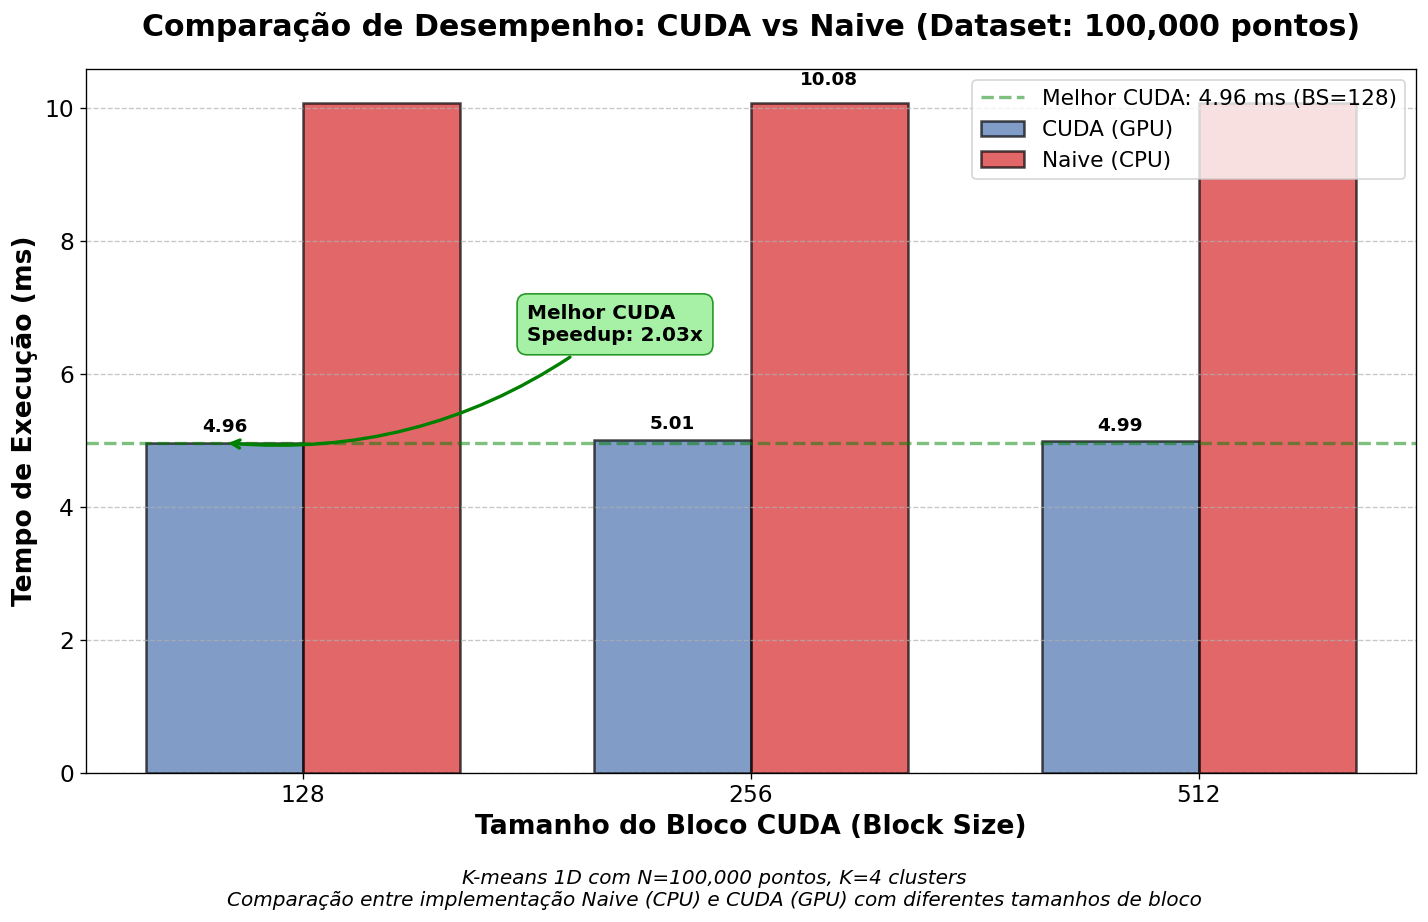

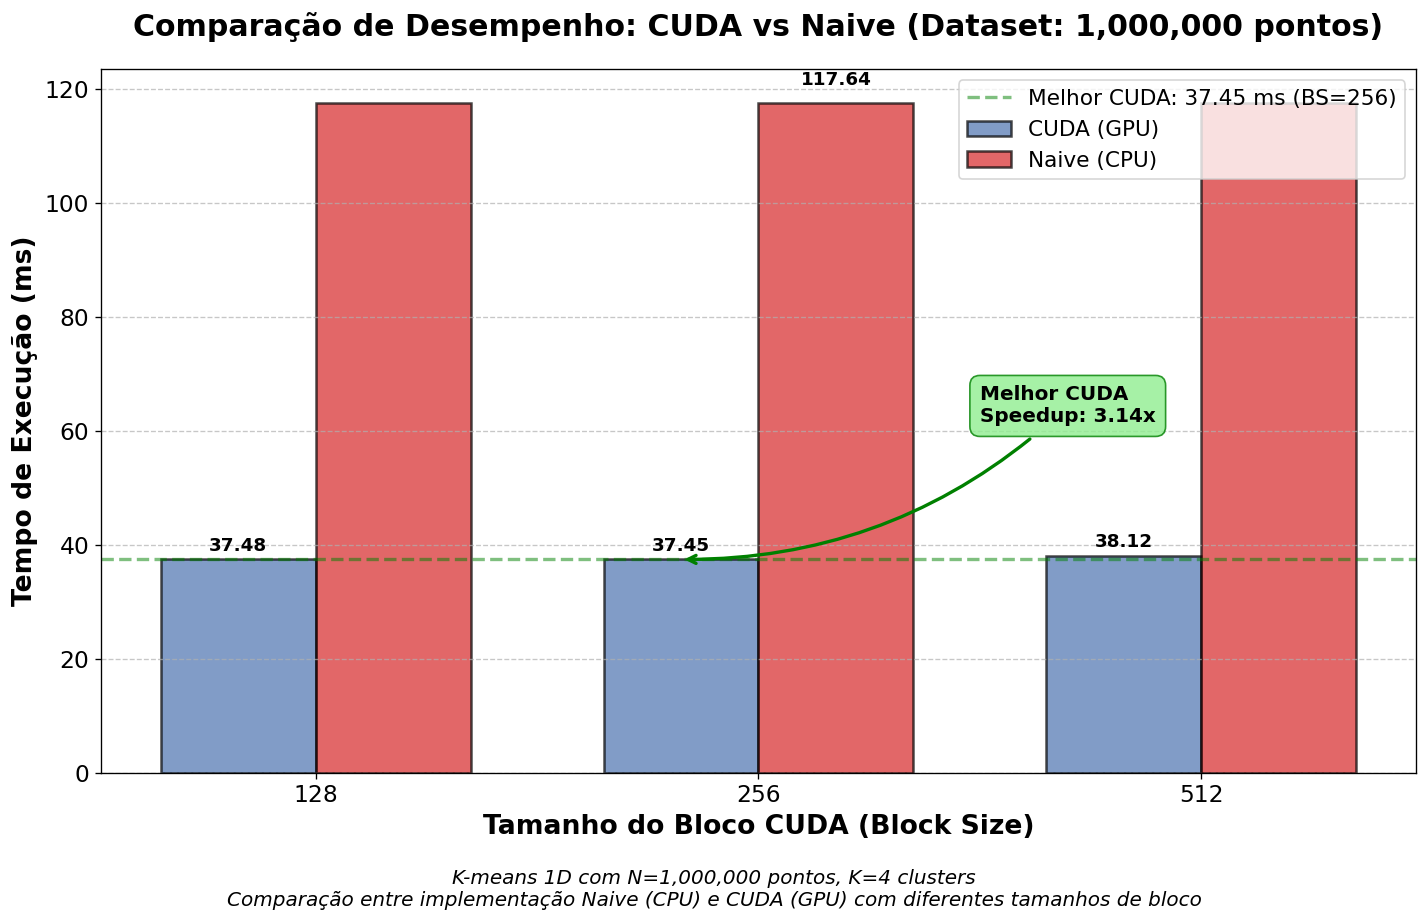

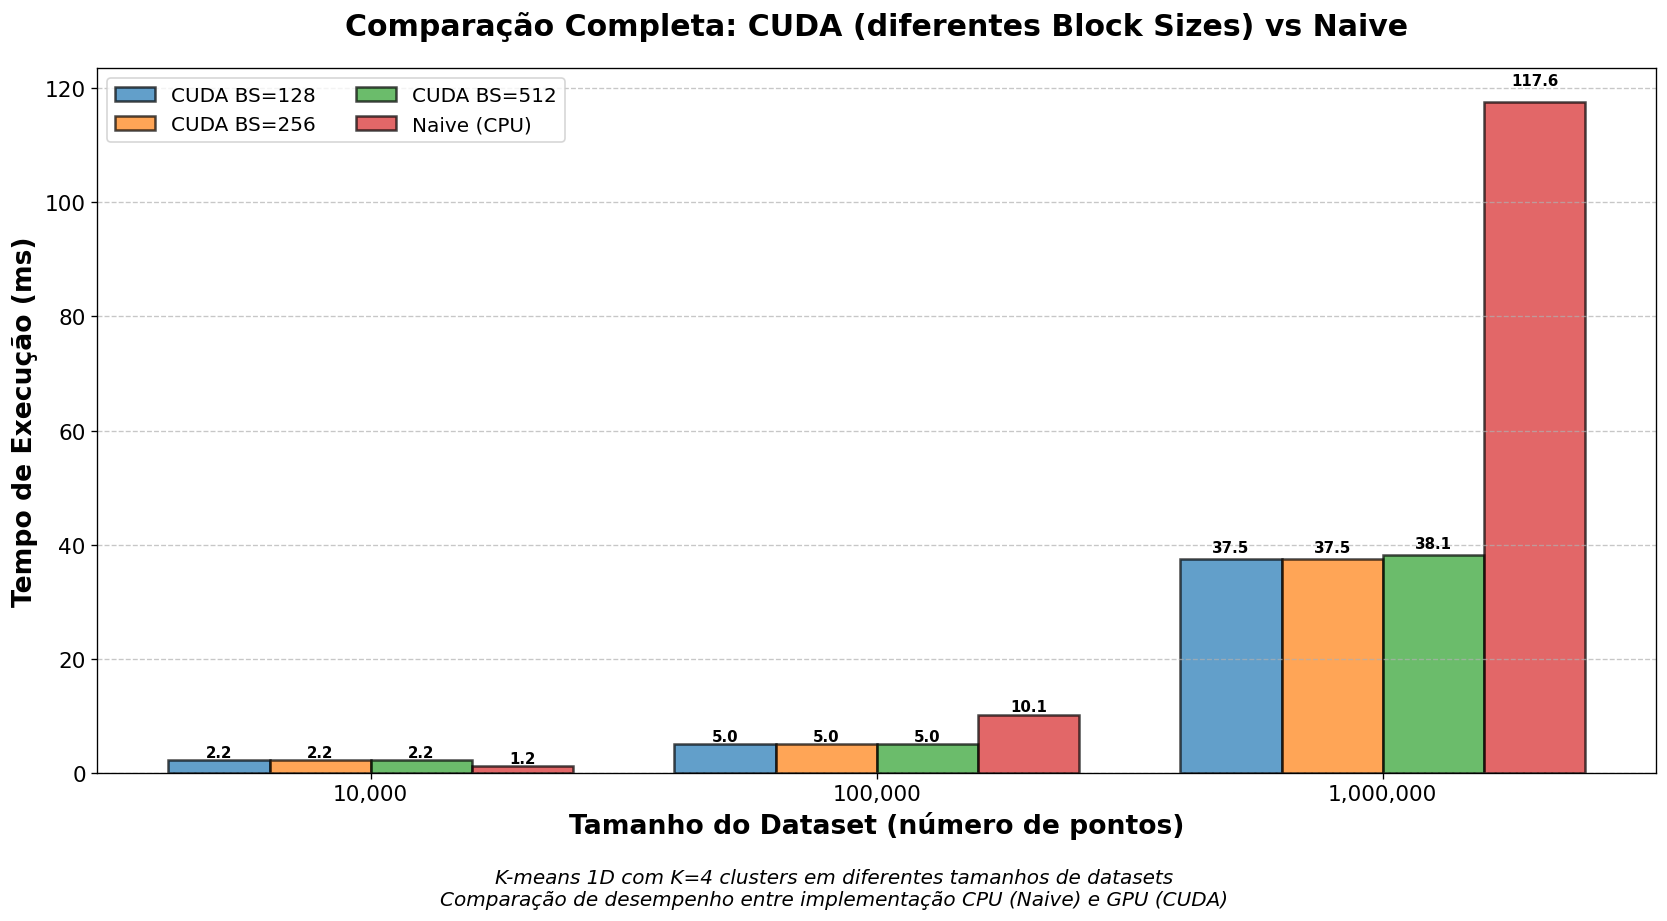

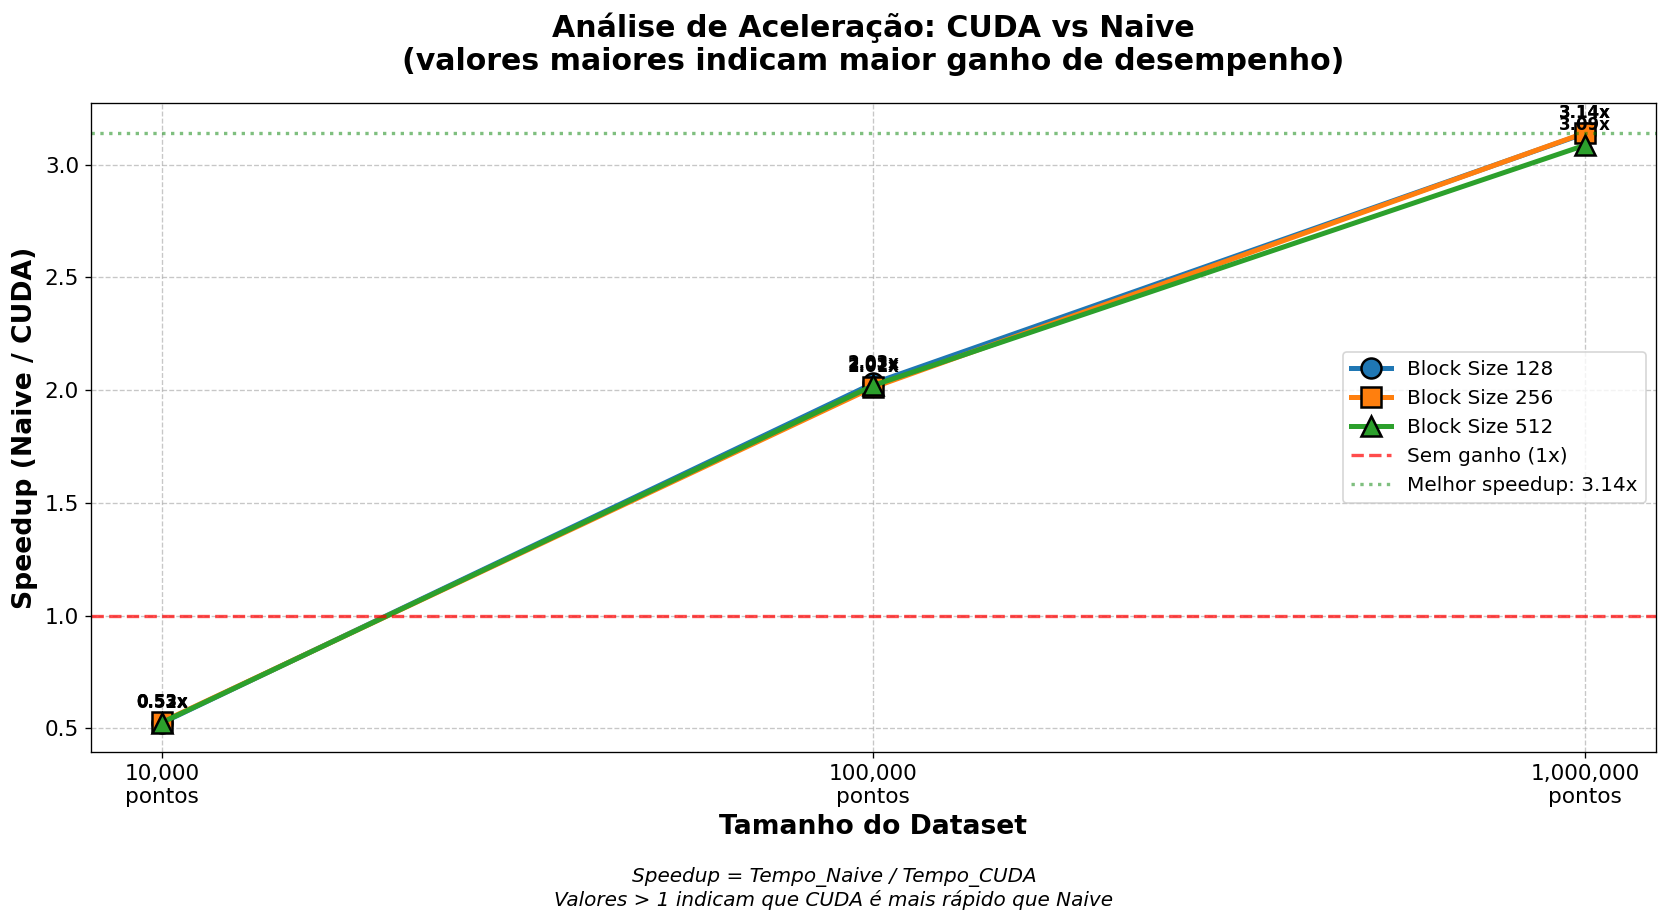

In [ ]:
import matplotlib.pyplot as plt
import re
import numpy as np

def parse_results_file(filename):
    """Parse results file and extract timing data"""
    data = {
        'naive': {},
        'cuda': {}
    }

    with open(filename, 'r') as f:
        content = f.read()

        # Extract naive results - looking for "Tempo: X.X ms"
        naive_pattern = r'Comando: \./kmeans_1d_naive (dados_\d+\.csv).*?Tempo: ([\d.]+) ms'
        naive_blocks = re.findall(naive_pattern, content, re.DOTALL)
        for dataset, time in naive_blocks:
            n_points = int(re.search(r'dados_(\d+)\.csv', dataset).group(1))
            if n_points not in data['naive']:
                data['naive'][n_points] = []
            data['naive'][n_points].append(float(time))

        # Extract CUDA results - looking for "Total: X.XXX ms"
        cuda_pattern = r'Comando: \./kmeans_1d_cuda (dados_\d+\.csv) centroides_iniciais\.csv (\d+).*?Total:\s+([\d.]+) ms'
        cuda_blocks = re.findall(cuda_pattern, content, re.DOTALL)
        for dataset, block_size, time in cuda_blocks:
            n_points = int(re.search(r'dados_(\d+)\.csv', dataset).group(1))
            bs = int(block_size)
            key = (n_points, bs)
            if key not in data['cuda']:
                data['cuda'][key] = []
            data['cuda'][key].append(float(time))

    return data

def calculate_averages(data):
    """Calculate average times from multiple runs"""
    avg_data = {
        'naive': {},
        'cuda': {}
    }

    for n_points, times in data['naive'].items():
        avg_data['naive'][n_points] = np.mean(times)

    for (n_points, bs), times in data['cuda'].items():
        avg_data['cuda'][(n_points, bs)] = np.mean(times)

    return avg_data

def plot_block_size_comparison_styled(avg_data, n_points):
    """Plot block size comparison for a specific dataset with styled bars"""
    block_sizes = [128, 256, 512]

    # Get CUDA times for different block sizes
    cuda_times = []
    for bs in block_sizes:
        key = (n_points, bs)
        if key in avg_data['cuda']:
            cuda_times.append(avg_data['cuda'][key])
        else:
            cuda_times.append(None)

    # Get naive time for comparison
    naive_time = avg_data['naive'].get(n_points, None)

    if not any(cuda_times) or naive_time is None:
        return

    # Create figure with high resolution
    plt.figure(figsize=(12, 8), dpi=120)

    # Set default style and enable grid
    plt.style.use('default')
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')

    # Define x positions and bar width
    x = np.arange(len(block_sizes))
    bar_width = 0.35

    # Create grouped bar chart
    cuda_bars = plt.bar(x - bar_width/2, cuda_times, bar_width,
                       label='CUDA (GPU)',
                       color='#4c72b0', edgecolor='black',
                       linewidth=1.5, alpha=0.7)

    # Add naive as reference bars
    naive_bars = plt.bar(x + bar_width/2, [naive_time]*len(block_sizes),
                        bar_width, label='Naive (CPU)',
                        color='#d62728', edgecolor='black',
                        linewidth=1.5, alpha=0.7)

    # Add title and axis labels
    plt.title(f'Comparação de Desempenho: CUDA vs Naive (Dataset: {n_points:,} pontos)',
             fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Tamanho do Bloco CUDA (Block Size)', fontsize=16, fontweight='bold')
    plt.ylabel('Tempo de Execução (ms)', fontsize=16, fontweight='bold')

    # Set x and y tick labels
    plt.xticks(x, block_sizes, fontsize=14)
    plt.yticks(fontsize=14)

    # Add value labels on top of CUDA bars
    for i, v in enumerate(cuda_times):
        if v is not None:
            plt.text(i - bar_width/2, v * 1.02, f'{v:.2f}',
                   ha='center', va='bottom', fontsize=11,
                   fontweight='bold', color='black')

    # Add value label on naive bar (only once, in the middle)
    plt.text(len(block_sizes)//2 + bar_width/2, naive_time * 1.02,
            f'{naive_time:.2f}',
            ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='black')

    # Find best CUDA performance
    best_cuda_time = min(t for t in cuda_times if t is not None)
    best_cuda_idx = cuda_times.index(best_cuda_time)
    best_block_size = block_sizes[best_cuda_idx]

    # Calculate speedup
    speedup = naive_time / best_cuda_time

    # Add annotation to highlight best performance
    plt.annotate(f'Melhor CUDA\nSpeedup: {speedup:.2f}x',
                xy=(best_cuda_idx - bar_width/2, best_cuda_time),
                xytext=(best_cuda_idx + 0.5, best_cuda_time + (naive_time - best_cuda_time)*0.3),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-.2",
                              linewidth=2, color='green'),
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", edgecolor="green",
                         facecolor="lightgreen", alpha=0.8))

    # Add horizontal reference line for best CUDA time
    plt.axhline(y=best_cuda_time, color='green', linestyle='--',
               alpha=0.5, linewidth=2,
               label=f'Melhor CUDA: {best_cuda_time:.2f} ms (BS={best_block_size})')

    # Add explanatory text at bottom
    plt.figtext(0.5, 0.01,
               f'K-means 1D com N={n_points:,} pontos, K=4 clusters\n'
               f'Comparação entre implementação Naive (CPU) e CUDA (GPU) com diferentes tamanhos de bloco',
               ha='center', fontsize=12, fontstyle='italic')

    # Add legend
    plt.legend(loc='upper right', fontsize=13)

    # Adjust layout
    plt.tight_layout(rect=[0, 0.06, 1, 0.96])

    # Save and show
    plt.savefig(f'comparison_styled_{n_points}.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

def plot_all_datasets_comparison(avg_data):
    """Plot comparison across all datasets with block sizes"""
    datasets = sorted(set(avg_data['naive'].keys()))
    block_sizes = [128, 256, 512]

    # Create figure with high resolution
    plt.figure(figsize=(14, 8), dpi=120)

    # Set default style and enable grid
    plt.style.use('default')
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')

    # Define x positions and bar width
    x = np.arange(len(datasets))
    bar_width = 0.2

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Plot CUDA times for each block size
    for i, bs in enumerate(block_sizes):
        times = []
        for n_points in datasets:
            key = (n_points, bs)
            if key in avg_data['cuda']:
                times.append(avg_data['cuda'][key])
            else:
                times.append(0)

        bars = plt.bar(x + i*bar_width, times, bar_width,
                      label=f'CUDA BS={bs}',
                      color=colors[i], edgecolor='black',
                      linewidth=1.5, alpha=0.7)

        # Add value labels
        for j, time in enumerate(times):
            if time > 0:
                plt.text(x[j] + i*bar_width, time * 1.02, f'{time:.1f}',
                        ha='center', va='bottom', fontsize=9,
                        fontweight='bold', rotation=0)

    # Plot Naive times
    naive_times = [avg_data['naive'][n] for n in datasets]
    bars = plt.bar(x + len(block_sizes)*bar_width, naive_times, bar_width,
                  label='Naive (CPU)',
                  color=colors[3], edgecolor='black',
                  linewidth=1.5, alpha=0.7)

    # Add value labels for Naive
    for j, time in enumerate(naive_times):
        plt.text(x[j] + len(block_sizes)*bar_width, time * 1.02, f'{time:.1f}',
                ha='center', va='bottom', fontsize=9,
                fontweight='bold', rotation=0)

    # Add title and axis labels
    plt.title('Comparação Completa: CUDA (diferentes Block Sizes) vs Naive',
             fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Tamanho do Dataset (número de pontos)', fontsize=16, fontweight='bold')
    plt.ylabel('Tempo de Execução (ms)', fontsize=16, fontweight='bold')

    # Set x tick labels
    plt.xticks(x + bar_width*1.5, [f'{n:,}' for n in datasets], fontsize=13)
    plt.yticks(fontsize=13)

    # Add explanatory text at bottom
    plt.figtext(0.5, 0.01,
               'K-means 1D com K=4 clusters em diferentes tamanhos de datasets\n'
               'Comparação de desempenho entre implementação CPU (Naive) e GPU (CUDA)',
               ha='center', fontsize=12, fontstyle='italic')

    # Add legend
    plt.legend(loc='upper left', fontsize=12, ncol=2)

    # Adjust layout
    plt.tight_layout(rect=[0, 0.06, 1, 0.96])

    # Save and show
    plt.savefig('comparison_all_datasets_styled.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

def plot_speedup_styled(avg_data):
    """Plot speedup with styled visualization"""
    datasets = sorted(set(avg_data['naive'].keys()))
    block_sizes = [128, 256, 512]

    # Create figure
    plt.figure(figsize=(14, 8), dpi=120)

    plt.style.use('default')
    plt.grid(True, linestyle='--', alpha=0.7)

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    markers = ['o', 's', '^']

    # Plot speedup for each block size
    for idx, bs in enumerate(block_sizes):
        speedups = []
        for n_points in datasets:
            if n_points not in avg_data['naive']:
                speedups.append(0)
                continue

            naive_time = avg_data['naive'][n_points]
            key = (n_points, bs)

            if key in avg_data['cuda']:
                cuda_time = avg_data['cuda'][key]
                speedup = naive_time / cuda_time if cuda_time > 0 else 0
                speedups.append(speedup)
            else:
                speedups.append(0)

        plt.plot(range(len(datasets)), speedups,
                marker=markers[idx], linestyle='-', linewidth=3,
                markersize=12, color=colors[idx],
                label=f'Block Size {bs}',
                markeredgecolor='black', markeredgewidth=1.5)

        # Add value labels
        for i, sp in enumerate(speedups):
            if sp > 0:
                plt.text(i, sp + 0.05, f'{sp:.2f}x',
                        ha='center', va='bottom', fontsize=10,
                        fontweight='bold')

    # Add reference line at speedup = 1
    plt.axhline(y=1, color='red', linestyle='--', linewidth=2,
               alpha=0.7, label='Sem ganho (1x)')

    # Highlight best overall speedup
    all_speedups = []
    for bs in block_sizes:
        for n_points in datasets:
            if n_points in avg_data['naive']:
                key = (n_points, bs)
                if key in avg_data['cuda']:
                    naive_time = avg_data['naive'][n_points]
                    cuda_time = avg_data['cuda'][key]
                    all_speedups.append(naive_time / cuda_time)

    if all_speedups:
        best_speedup = max(all_speedups)
        plt.axhline(y=best_speedup, color='green', linestyle=':',
                   linewidth=2, alpha=0.5,
                   label=f'Melhor speedup: {best_speedup:.2f}x')

    plt.xlabel('Tamanho do Dataset', fontsize=16, fontweight='bold')
    plt.ylabel('Speedup (Naive / CUDA)', fontsize=16, fontweight='bold')
    plt.title('Análise de Aceleração: CUDA vs Naive\n(valores maiores indicam maior ganho de desempenho)',
             fontsize=18, fontweight='bold', pad=20)

    plt.xticks(range(len(datasets)), [f'{n:,}\npontos' for n in datasets], fontsize=13)
    plt.yticks(fontsize=13)

    plt.figtext(0.5, 0.01,
               'Speedup = Tempo_Naive / Tempo_CUDA\n'
               'Valores > 1 indicam que CUDA é mais rápido que Naive',
               ha='center', fontsize=12, fontstyle='italic')

    plt.legend(loc='best', fontsize=12)
    plt.tight_layout(rect=[0, 0.06, 1, 0.96])

    plt.savefig('speedup_styled.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

def print_summary_table(avg_data):
    """Print a summary table of all results"""
    datasets = sorted(set(avg_data['naive'].keys()))
    block_sizes = [128, 256, 512]

    for n_points in datasets:
        print(f"\n{'─'*100}")
        print(f"Dataset: {n_points:,} pontos")
        print(f"{'─'*100}")

        if n_points in avg_data['naive']:
            naive_time = avg_data['naive'][n_points]

            best_cuda_time = float('inf')
            best_bs = None

            for bs in block_sizes:
                key = (n_points, bs)
                if key in avg_data['cuda']:
                    cuda_time = avg_data['cuda'][key]
                    speedup = naive_time / cuda_time if cuda_time > 0 else 0
                    efficiency = (speedup / 1) * 100  # Assuming single GPU

def main():
    all_data = {
        'naive': {},
        'cuda': {}
    }

    files_found = 0
    for run in range(1, 6):
        filename = f'results_all_{run}.txt'
        try:
            data = parse_results_file(filename)

            for n_points, times in data['naive'].items():
                if n_points not in all_data['naive']:
                    all_data['naive'][n_points] = []
                all_data['naive'][n_points].extend(times)

            for key, times in data['cuda'].items():
                if key not in all_data['cuda']:
                    all_data['cuda'][key] = []
                all_data['cuda'][key].extend(times)

            files_found += 1
            print(f" {filename}")
        except FileNotFoundError:
            print(f" {filename} não encontrado")

    if files_found == 0:
        print("\n Erro: Nenhum arquivo de resultado encontrado!")
        return

    avg_data = calculate_averages(all_data)

    print_summary_table(avg_data)

    # Generate individual styled plots for each dataset
    datasets = sorted(set(avg_data['naive'].keys()))
    for n_points in datasets:
        plot_block_size_comparison_styled(avg_data, n_points)

    # Generate combined plots
    plot_all_datasets_comparison(avg_data)
    plot_speedup_styled(avg_data)

if __name__ == "__main__":
    main()

/tmp/ipython-input-3218010467.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 4)


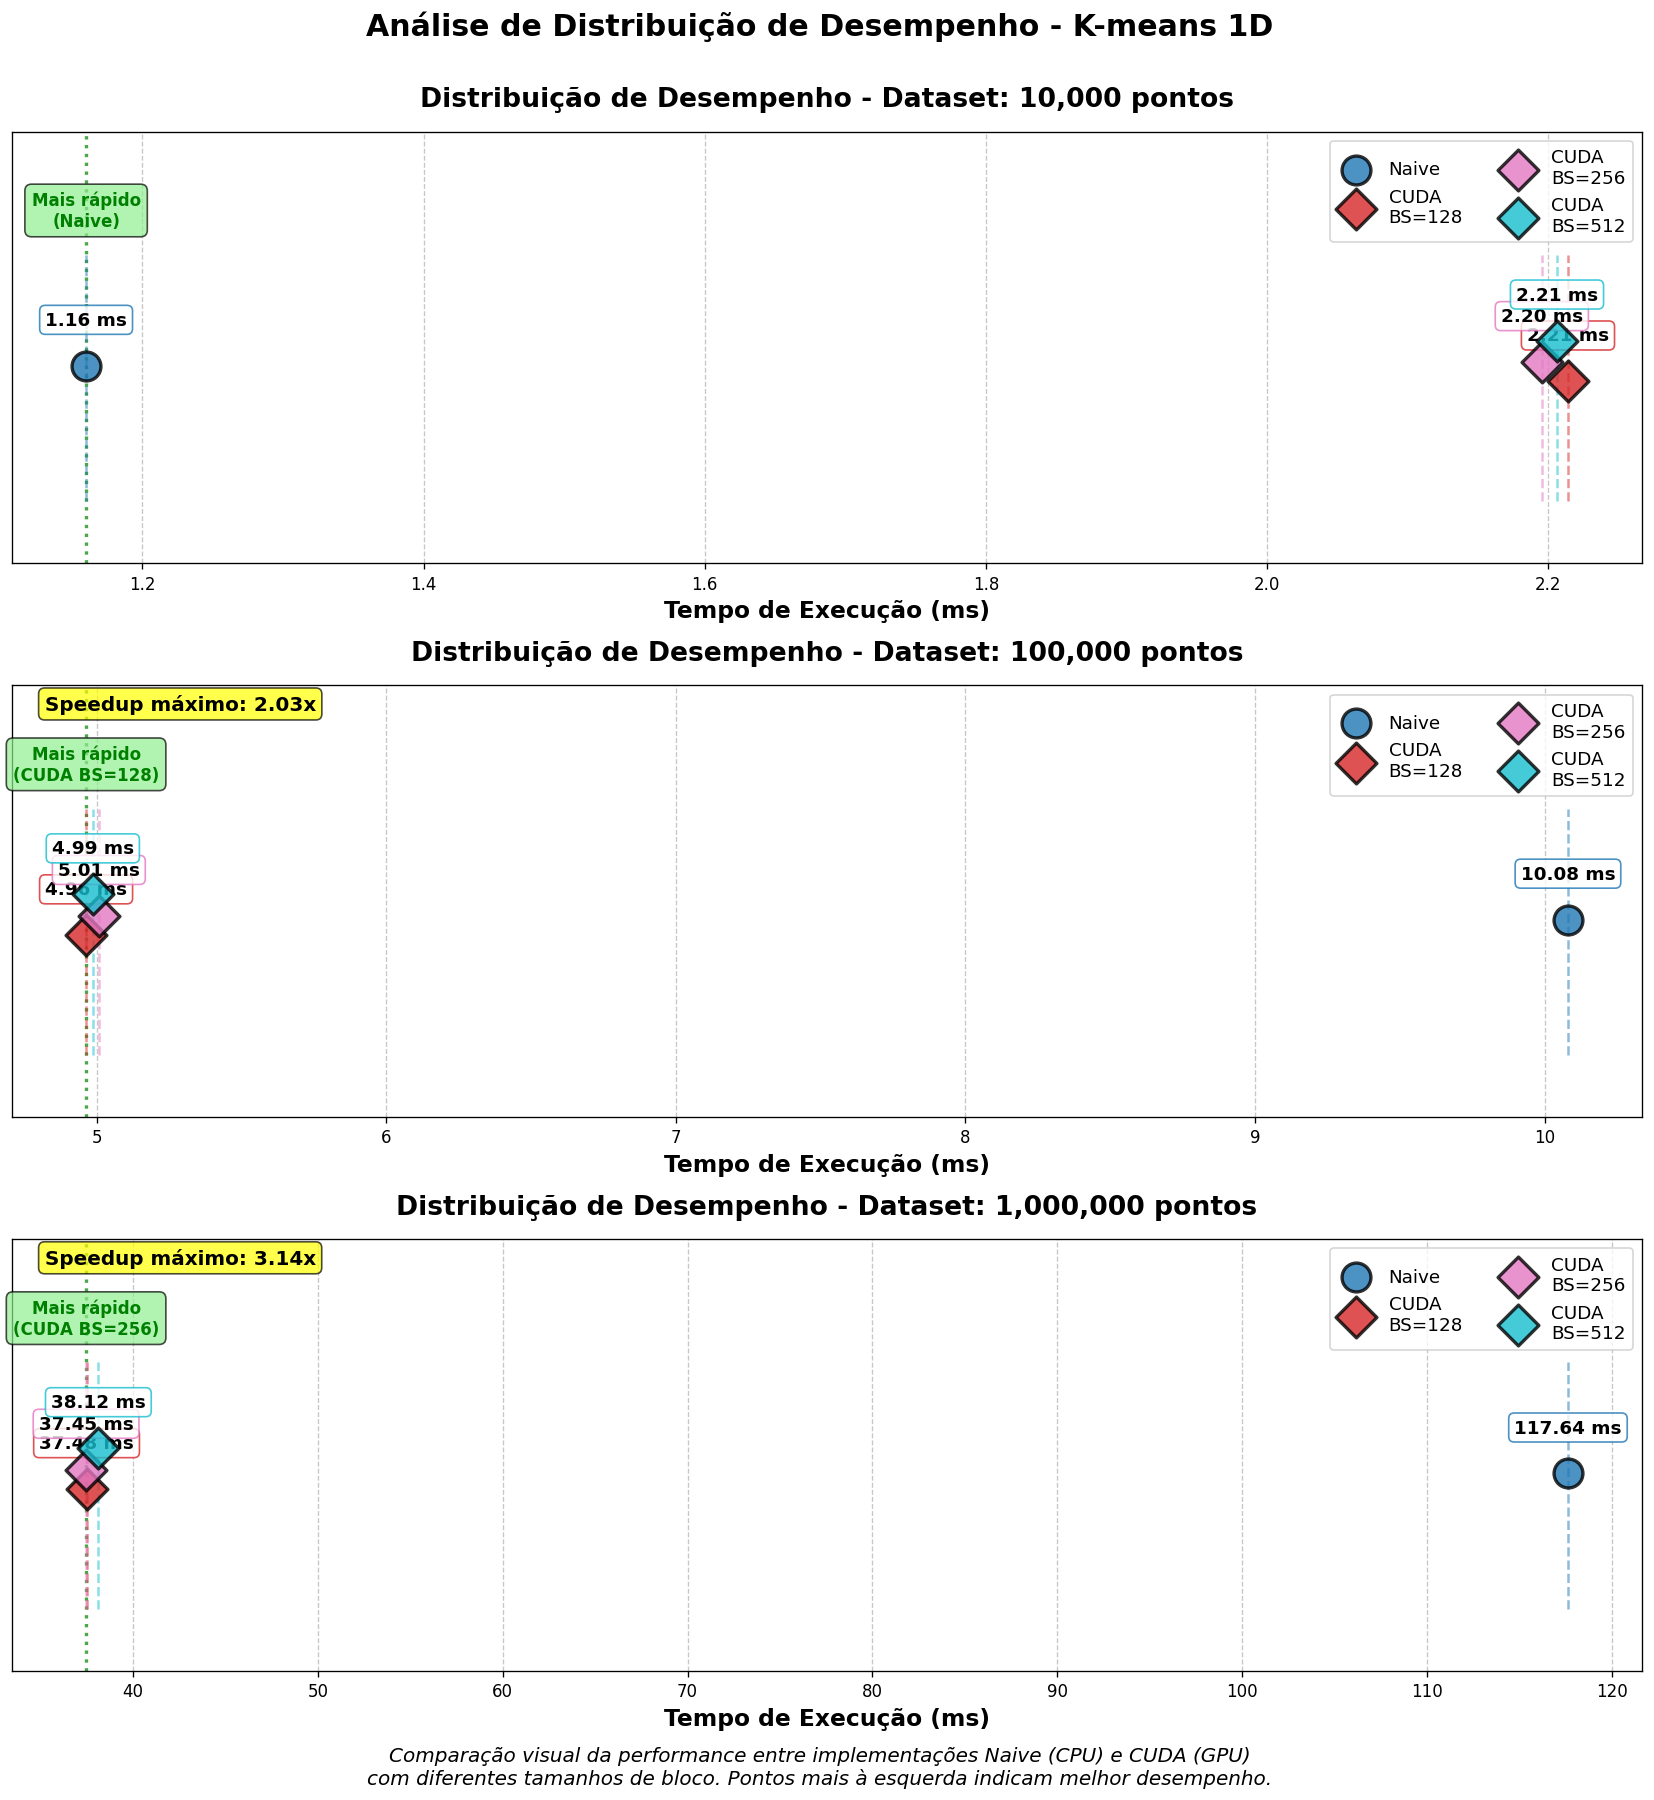

/tmp/ipython-input-3218010467.py:154: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 4)


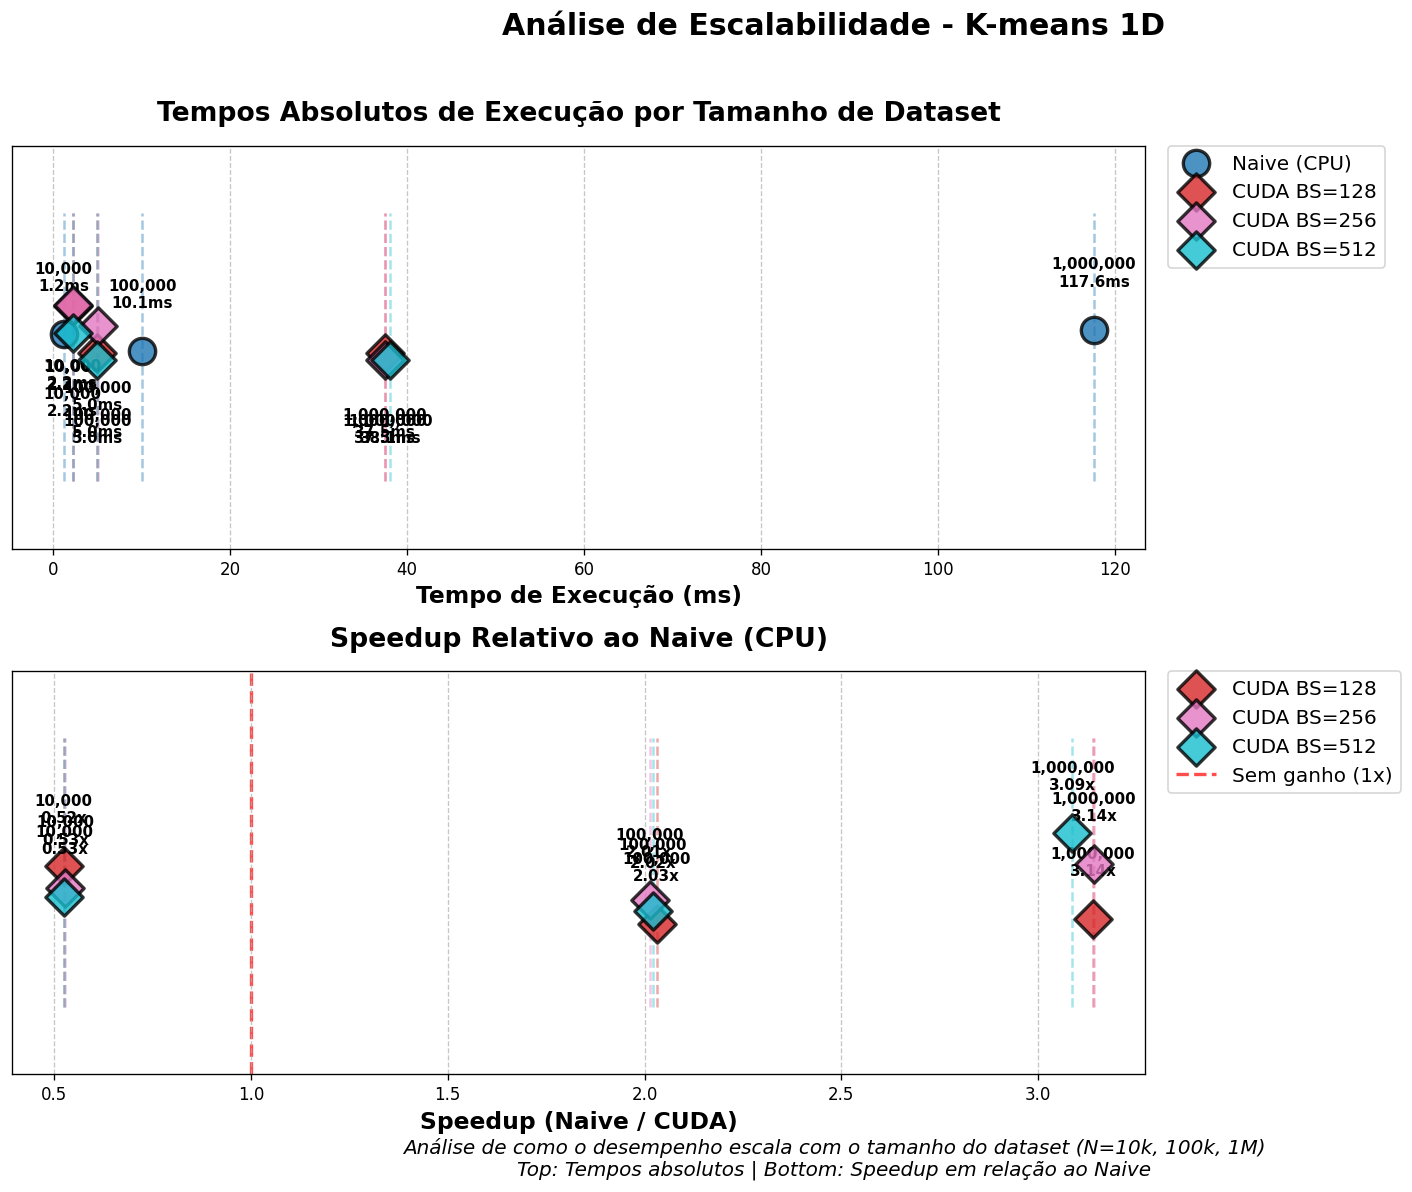

/tmp/ipython-input-3218010467.py:279: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', 10)


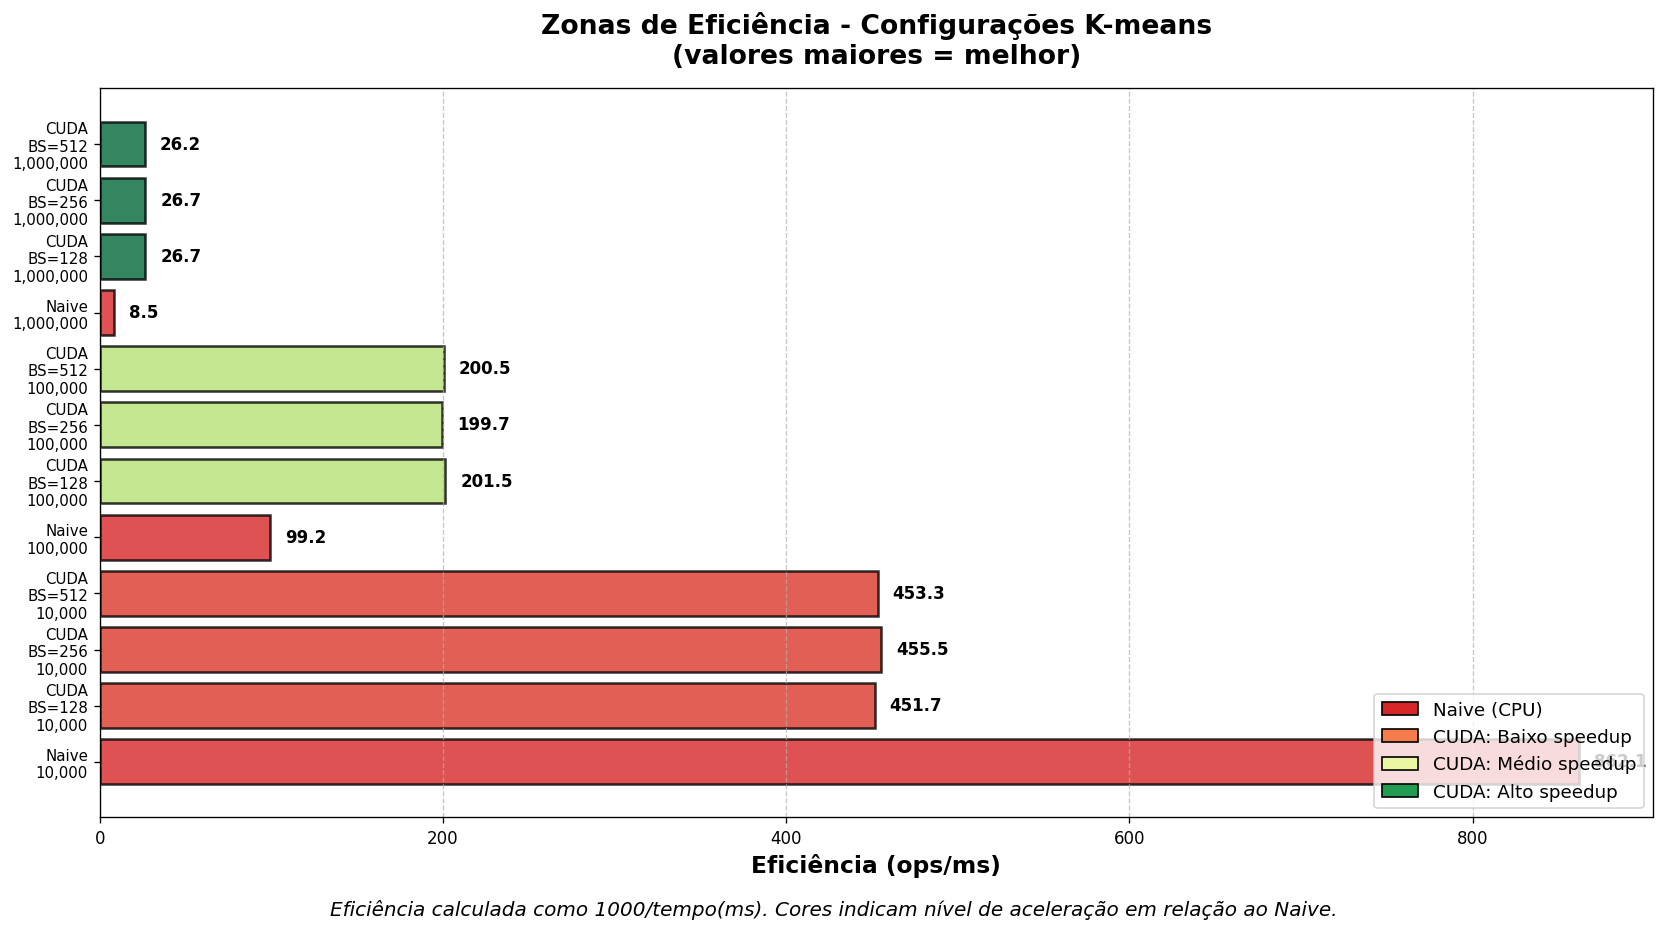

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re

def parse_results_file(filename):
    """Parse results file and extract timing data"""
    data = {
        'naive': {},
        'cuda': {}
    }

    with open(filename, 'r') as f:
        content = f.read()

        # Extract naive results
        naive_pattern = r'Comando: \./kmeans_1d_naive (dados_\d+\.csv).*?Tempo: ([\d.]+) ms'
        naive_blocks = re.findall(naive_pattern, content, re.DOTALL)
        for dataset, time in naive_blocks:
            n_points = int(re.search(r'dados_(\d+)\.csv', dataset).group(1))
            if n_points not in data['naive']:
                data['naive'][n_points] = []
            data['naive'][n_points].append(float(time))

        # Extract CUDA results
        cuda_pattern = r'Comando: \./kmeans_1d_cuda (dados_\d+\.csv) centroides_iniciais\.csv (\d+).*?Total:\s+([\d.]+) ms'
        cuda_blocks = re.findall(cuda_pattern, content, re.DOTALL)
        for dataset, block_size, time in cuda_blocks:
            n_points = int(re.search(r'dados_(\d+)\.csv', dataset).group(1))
            bs = int(block_size)
            key = (n_points, bs)
            if key not in data['cuda']:
                data['cuda'][key] = []
            data['cuda'][key].append(float(time))

    return data

def calculate_averages(data):
    """Calculate average times from multiple runs"""
    avg_data = {
        'naive': {},
        'cuda': {}
    }

    for n_points, times in data['naive'].items():
        avg_data['naive'][n_points] = np.mean(times)

    for (n_points, bs), times in data['cuda'].items():
        avg_data['cuda'][(n_points, bs)] = np.mean(times)

    return avg_data

def visualize_performance_distribution(avg_data):
    """Visualize performance distribution across configurations"""
    datasets = sorted(set(avg_data['naive'].keys()))
    block_sizes = [128, 256, 512]

    # Create figure with subplots for each dataset
    fig, axes = plt.subplots(len(datasets), 1, figsize=(14, 5*len(datasets)), dpi=120)

    if len(datasets) == 1:
        axes = [axes]

    # Generate colors
    cmap = plt.cm.get_cmap('tab10', 4)
    colors = [cmap(i) for i in range(4)]

    for idx, n_points in enumerate(datasets):
        ax = axes[idx]

        # Prepare data
        methods = ['Naive'] + [f'CUDA\nBS={bs}' for bs in block_sizes]
        times = [avg_data['naive'][n_points]]

        for bs in block_sizes:
            key = (n_points, bs)
            if key in avg_data['cuda']:
                times.append(avg_data['cuda'][key])
            else:
                times.append(0)

        # Create jittered y positions for visual effect
        np.random.seed(42)
        y_positions = np.random.normal(0, 0.02, size=len(times))

        # Plot as scatter with lines
        for i, (method, time) in enumerate(zip(methods, times)):
            if time > 0:
                ax.scatter(time, y_positions[i], s=300, c=[colors[i]],
                          edgecolor='black', linewidth=2, zorder=3,
                          marker='o' if i == 0 else 'D',
                          label=method, alpha=0.8)

                # Add vertical reference line
                ax.plot([time, time], [-0.1, 0.1], '--',
                       color=colors[i], alpha=0.5, linewidth=1.5)

                # Add value label
                ax.text(time, y_positions[i] + 0.03, f'{time:.2f} ms',
                       ha='center', va='bottom', fontsize=11,
                       fontweight='bold', bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor=colors[i], alpha=0.8))

        # Highlight fastest method
        min_time = min(t for t in times if t > 0)
        min_idx = times.index(min_time)
        ax.axvline(x=min_time, color='green', linestyle=':',
                  linewidth=2, alpha=0.7, zorder=1)
        ax.text(min_time, 0.12, f'Mais rápido\n({methods[min_idx].replace(chr(10), " ")})',
               ha='center', va='bottom', fontsize=10,
               fontweight='bold', color='green',
               bbox=dict(boxstyle='round,pad=0.4',
                        facecolor='lightgreen', alpha=0.7))

        # Customize plot
        ax.set_title(f'Distribuição de Desempenho - Dataset: {n_points:,} pontos',
                    fontsize=16, fontweight='bold', pad=15)
        ax.set_xlabel('Tempo de Execução (ms)', fontsize=14, fontweight='bold')
        ax.set_yticks([])
        ax.set_ylim(-0.15, 0.20)
        ax.grid(True, linestyle='--', alpha=0.7, axis='x')
        ax.legend(fontsize=11, loc='upper right', ncol=2)

        # Calculate and show speedup
        if min_idx > 0:  # If CUDA is fastest
            naive_time = times[0]
            speedup = naive_time / min_time
            ax.text(0.02, 0.98, f'Speedup máximo: {speedup:.2f}x',
                   transform=ax.transAxes, fontsize=12, fontweight='bold',
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

    # Add overall title and description
    plt.suptitle('Análise de Distribuição de Desempenho - K-means 1D',
                fontsize=18, fontweight='bold', y=0.995)
    plt.figtext(0.5, 0.01,
               'Comparação visual da performance entre implementações Naive (CPU) e CUDA (GPU)\n'
               'com diferentes tamanhos de bloco. Pontos mais à esquerda indicam melhor desempenho.',
               ha='center', fontsize=12, fontstyle='italic')

    plt.tight_layout(rect=[0, 0.03, 1, 0.99])
    plt.savefig('performance_distribution.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

def visualize_scalability_analysis(avg_data):
    """Visualize how performance scales with dataset size"""
    datasets = sorted(set(avg_data['naive'].keys()))
    block_sizes = [128, 256, 512]

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), dpi=120)

    # Colors
    cmap = plt.cm.get_cmap('tab10', 4)
    colors = [cmap(i) for i in range(4)]

    # ---- BEFORE: Show absolute times ----
    np.random.seed(42)

    # Plot Naive
    naive_times = [avg_data['naive'][n] for n in datasets]
    y_naive = np.random.normal(0, 0.02, size=len(datasets))

    for i, (n_points, time, y) in enumerate(zip(datasets, naive_times, y_naive)):
        ax1.scatter(time, y, s=250, c=[colors[0]],
                   edgecolor='black', linewidth=2, zorder=3,
                   marker='o', alpha=0.8)
        ax1.plot([time, time], [-0.1, 0.1], '--',
                color=colors[0], alpha=0.4, linewidth=1.5)
        ax1.text(time, y + 0.03, f'{n_points:,}\n{time:.1f}ms',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax1.scatter([], [], s=250, c=[colors[0]], edgecolor='black',
               linewidth=2, marker='o', label='Naive (CPU)', alpha=0.8)

    # Plot CUDA configurations
    for bs_idx, bs in enumerate(block_sizes, 1):
        cuda_times = []
        y_cuda = []
        valid_datasets = []

        for n_points in datasets:
            key = (n_points, bs)
            if key in avg_data['cuda']:
                cuda_times.append(avg_data['cuda'][key])
                y_cuda.append(np.random.normal(0, 0.02))
                valid_datasets.append(n_points)

        for i, (n_points, time, y) in enumerate(zip(valid_datasets, cuda_times, y_cuda)):
            ax1.scatter(time, y, s=250, c=[colors[bs_idx]],
                       edgecolor='black', linewidth=2, zorder=3,
                       marker='D', alpha=0.8)
            ax1.plot([time, time], [-0.1, 0.1], '--',
                    color=colors[bs_idx], alpha=0.4, linewidth=1.5)
            ax1.text(time, y - 0.04, f'{n_points:,}\n{time:.1f}ms',
                    ha='center', va='top', fontsize=9, fontweight='bold')

        ax1.scatter([], [], s=250, c=[colors[bs_idx]], edgecolor='black',
                   linewidth=2, marker='D', label=f'CUDA BS={bs}', alpha=0.8)

    ax1.set_title('Tempos Absolutos de Execução por Tamanho de Dataset',
                 fontsize=16, fontweight='bold', pad=15)
    ax1.set_xlabel('Tempo de Execução (ms)', fontsize=14, fontweight='bold')
    ax1.set_yticks([])
    ax1.set_ylim(-0.15, 0.15)
    ax1.grid(True, linestyle='--', alpha=0.7, axis='x')
    ax1.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

    # ---- AFTER: Show speedups ----
    for bs_idx, bs in enumerate(block_sizes):
        speedups = []
        valid_datasets = []
        y_speedup = []

        for n_points in datasets:
            if n_points not in avg_data['naive']:
                continue

            naive_time = avg_data['naive'][n_points]
            key = (n_points, bs)

            if key in avg_data['cuda']:
                cuda_time = avg_data['cuda'][key]
                speedup = naive_time / cuda_time
                speedups.append(speedup)
                valid_datasets.append(n_points)
                y_speedup.append(np.random.normal(0, 0.02))

        for i, (n_points, speedup, y) in enumerate(zip(valid_datasets, speedups, y_speedup)):
            ax2.scatter(speedup, y, s=250, c=[colors[bs_idx + 1]],
                       edgecolor='black', linewidth=2, zorder=3,
                       marker='D', alpha=0.8)
            ax2.plot([speedup, speedup], [-0.1, 0.1], '--',
                    color=colors[bs_idx + 1], alpha=0.4, linewidth=1.5)
            ax2.text(speedup, y + 0.03, f'{n_points:,}\n{speedup:.2f}x',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax2.scatter([], [], s=250, c=[colors[bs_idx + 1]], edgecolor='black',
                   linewidth=2, marker='D', label=f'CUDA BS={bs}', alpha=0.8)

    # Add reference line at speedup = 1
    ax2.axvline(x=1, color='red', linestyle='--', linewidth=2,
               alpha=0.7, label='Sem ganho (1x)', zorder=1)

    ax2.set_title('Speedup Relativo ao Naive (CPU)',
                 fontsize=16, fontweight='bold', pad=15)
    ax2.set_xlabel('Speedup (Naive / CUDA)', fontsize=14, fontweight='bold')
    ax2.set_yticks([])
    ax2.set_ylim(-0.15, 0.15)
    ax2.grid(True, linestyle='--', alpha=0.7, axis='x')
    ax2.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

    # Add overall title and description
    plt.suptitle('Análise de Escalabilidade - K-means 1D',
                fontsize=18, fontweight='bold', y=0.98)
    plt.figtext(0.5, 0.01,
               'Análise de como o desempenho escala com o tamanho do dataset (N=10k, 100k, 1M)\n'
               'Top: Tempos absolutos | Bottom: Speedup em relação ao Naive',
               ha='center', fontsize=12, fontstyle='italic')

    plt.tight_layout(rect=[0, 0.03, 0.85, 0.96])
    plt.savefig('scalability_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

def visualize_efficiency_zones(avg_data):
    """Visualize efficiency zones for different configurations"""
    datasets = sorted(set(avg_data['naive'].keys()))
    block_sizes = [128, 256, 512]

    fig, ax = plt.subplots(figsize=(14, 8), dpi=120)

    # Calculate efficiency (inverse of time)
    configurations = []
    efficiencies = []
    labels = []
    colors_list = []

    cmap = plt.cm.get_cmap('RdYlGn', 10)

    for n_points in datasets:
        # Naive
        if n_points in avg_data['naive']:
            naive_time = avg_data['naive'][n_points]
            efficiency = 1000 / naive_time  # ops/ms
            configurations.append(len(configurations))
            efficiencies.append(efficiency)
            labels.append(f'Naive\n{n_points:,}')
            colors_list.append('#d62728')

        # CUDA
        for bs in block_sizes:
            key = (n_points, bs)
            if key in avg_data['cuda']:
                cuda_time = avg_data['cuda'][key]
                efficiency = 1000 / cuda_time
                speedup = naive_time / cuda_time

                configurations.append(len(configurations))
                efficiencies.append(efficiency)
                labels.append(f'CUDA\nBS={bs}\n{n_points:,}')

                # Color based on speedup
                color_idx = min(9, int(speedup * 3))
                colors_list.append(cmap(color_idx))

    # Create horizontal bar chart
    y_pos = np.arange(len(configurations))
    bars = ax.barh(y_pos, efficiencies, color=colors_list,
                   edgecolor='black', linewidth=1.5, alpha=0.8)

    # Add value labels
    for i, (bar, eff) in enumerate(zip(bars, efficiencies)):
        width = bar.get_width()
        ax.text(width + max(efficiencies)*0.01, bar.get_y() + bar.get_height()/2,
               f'{eff:.1f}',
               ha='left', va='center', fontsize=10, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Eficiência (ops/ms)', fontsize=14, fontweight='bold')
    ax.set_title('Zonas de Eficiência - Configurações K-means\n(valores maiores = melhor)',
                fontsize=16, fontweight='bold', pad=15)
    ax.grid(True, linestyle='--', alpha=0.7, axis='x')

    # Add color legend
    from matplotlib.patches import Rectangle
    legend_elements = [
        Rectangle((0, 0), 1, 1, fc='#d62728', edgecolor='black', label='Naive (CPU)'),
        Rectangle((0, 0), 1, 1, fc=cmap(2), edgecolor='black', label='CUDA: Baixo speedup'),
        Rectangle((0, 0), 1, 1, fc=cmap(5), edgecolor='black', label='CUDA: Médio speedup'),
        Rectangle((0, 0), 1, 1, fc=cmap(8), edgecolor='black', label='CUDA: Alto speedup')
    ]
    ax.legend(handles=legend_elements, fontsize=11, loc='lower right')

    plt.figtext(0.5, 0.01,
               'Eficiência calculada como 1000/tempo(ms). Cores indicam nível de aceleração em relação ao Naive.',
               ha='center', fontsize=12, fontstyle='italic')

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.savefig('efficiency_zones.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

def main():
    all_data = {
        'naive': {},
        'cuda': {}
    }

    files_found = 0
    for run in range(1, 6):
        filename = f'results_all_{run}.txt'
        try:
            data = parse_results_file(filename)

            for n_points, times in data['naive'].items():
                if n_points not in all_data['naive']:
                    all_data['naive'][n_points] = []
                all_data['naive'][n_points].extend(times)

            for key, times in data['cuda'].items():
                if key not in all_data['cuda']:
                    all_data['cuda'][key] = []
                all_data['cuda'][key].extend(times)

            files_found += 1
        except FileNotFoundError:
            print(f"{filename} não encontrado")

    if files_found == 0:
        print("\nErro: Nenhum arquivo de resultado encontrado!")
        return

    avg_data = calculate_averages(all_data)

    visualize_performance_distribution(avg_data)
    visualize_scalability_analysis(avg_data)
    visualize_efficiency_zones(avg_data)

if __name__ == "__main__":
    main()